In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

%matplotlib inline


In [3]:
data = pd.read_csv('Algerian_forest_fires_dataset_Cleaned_me.csv')
data

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
0,1,6,2012,29,57,18,0.0,65.7,3.4,7.6,1.3,3.4,0.5,not fire,0
1,2,6,2012,29,61,13,1.3,64.4,4.1,7.6,1.0,3.9,0.4,not fire,0
2,3,6,2012,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,not fire,0
3,4,6,2012,25,89,13,2.5,28.6,1.3,6.9,0.0,1.7,0.0,not fire,0
4,5,6,2012,27,77,16,0.0,64.8,3.0,14.2,1.2,3.9,0.5,not fire,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
239,26,9,2012,30,65,14,0.0,85.4,16.0,44.5,4.5,16.9,6.5,fire,1
240,27,9,2012,28,87,15,4.4,41.1,6.5,8.0,0.1,6.2,0.0,not fire,1
241,28,9,2012,27,87,29,0.5,45.9,3.5,7.9,0.4,3.4,0.2,not fire,1
242,29,9,2012,24,54,18,0.1,79.7,4.3,15.2,1.7,5.1,0.7,not fire,1


In [4]:
# As it is a regression problem is solved here
# where we predict FWI base don other features
# we can eleminate the day, month, year columns

data.drop(['day','month','year'],axis= 1,inplace=True)

In [5]:
data

,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
0,29,57,18,0.0,65.7,3.4,7.6,1.3,3.4,0.5,not fire,0
1,29,61,13,1.3,64.4,4.1,7.6,1.0,3.9,0.4,not fire,0
2,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,not fire,0
3,25,89,13,2.5,28.6,1.3,6.9,0.0,1.7,0.0,not fire,0
4,27,77,16,0.0,64.8,3.0,14.2,1.2,3.9,0.5,not fire,0
...,...,...,...,...,...,...,...,...,...,...,...,...
239,30,65,14,0.0,85.4,16.0,44.5,4.5,16.9,6.5,fire,1
240,28,87,15,4.4,41.1,6.5,8.0,0.1,6.2,0.0,not fire,1
241,27,87,29,0.5,45.9,3.5,7.9,0.4,3.4,0.2,not fire,1
242,24,54,18,0.1,79.7,4.3,15.2,1.7,5.1,0.7,not fire,1


In [6]:
data.Classes.value_counts()

Classes
fire             132
not fire         101
fire               4
fire               2
not fire           2
not fire           1
not fire           1
not fire           1
Name: count, dtype: int64

In [7]:
data['Classes']=np.where(data['Classes'].str.contains('not fire'),0,1)

In [8]:
data.Classes.value_counts()

Classes
1    138
0    106
Name: count, dtype: int64

In [9]:
X =data.drop(['FWI'],axis=1)
y= data['FWI']

In [10]:
X['Classes'].value_counts()

Classes
1    138
0    106
Name: count, dtype: int64

In [11]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.25,random_state=45)

In [12]:
X_train.shape,X_test.shape

((183, 11), (61, 11))

In [13]:
# feature selection based on correlation
X_train.corr()

,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,Classes,Region
Temperature,1.000000,-0.690479,-0.324198,-0.357882,0.684972,0.477102,0.355995,0.608502,0.444543,0.528056,0.309498
RH,-0.690479,1.000000,0.228944,0.250569,-0.675737,-0.435936,-0.245337,-0.724585,-0.375818,-0.475600,-0.432015
Ws,-0.324198,0.228944,1.000000,0.239092,-0.174093,0.002229,0.087999,-0.013656,0.036653,-0.083452,-0.174769
Rain,-0.357882,0.250569,0.239092,1.000000,-0.548253,-0.287327,-0.297429,-0.342437,-0.297902,-0.367002,-0.073956
FFMC,0.684972,-0.675737,-0.174093,-0.548253,1.000000,0.600047,0.503707,0.739878,0.587100,0.771388,0.217579
DMC,0.477102,-0.435936,0.002229,-0.287327,0.600047,1.000000,0.879618,0.682263,0.982134,0.563353,0.185447
DC,0.355995,-0.245337,0.087999,-0.297429,0.503707,0.879618,1.000000,0.505144,0.942206,0.470435,-0.099443
ISI,0.608502,-0.724585,-0.013656,-0.342437,0.739878,0.682263,0.505144,1.000000,0.640862,0.737981,0.283068
BUI,0.444543,-0.375818,0.036653,-0.297902,0.587100,0.982134,0.942206,0.640862,1.000000,0.558010,0.074911
Classes,0.528056,-0.475600,-0.083452,-0.367002,0.771388,0.563353,0.470435,0.737981,0.558010,1.000000,0.153692


# check for multi-colinearity


<Axes: >

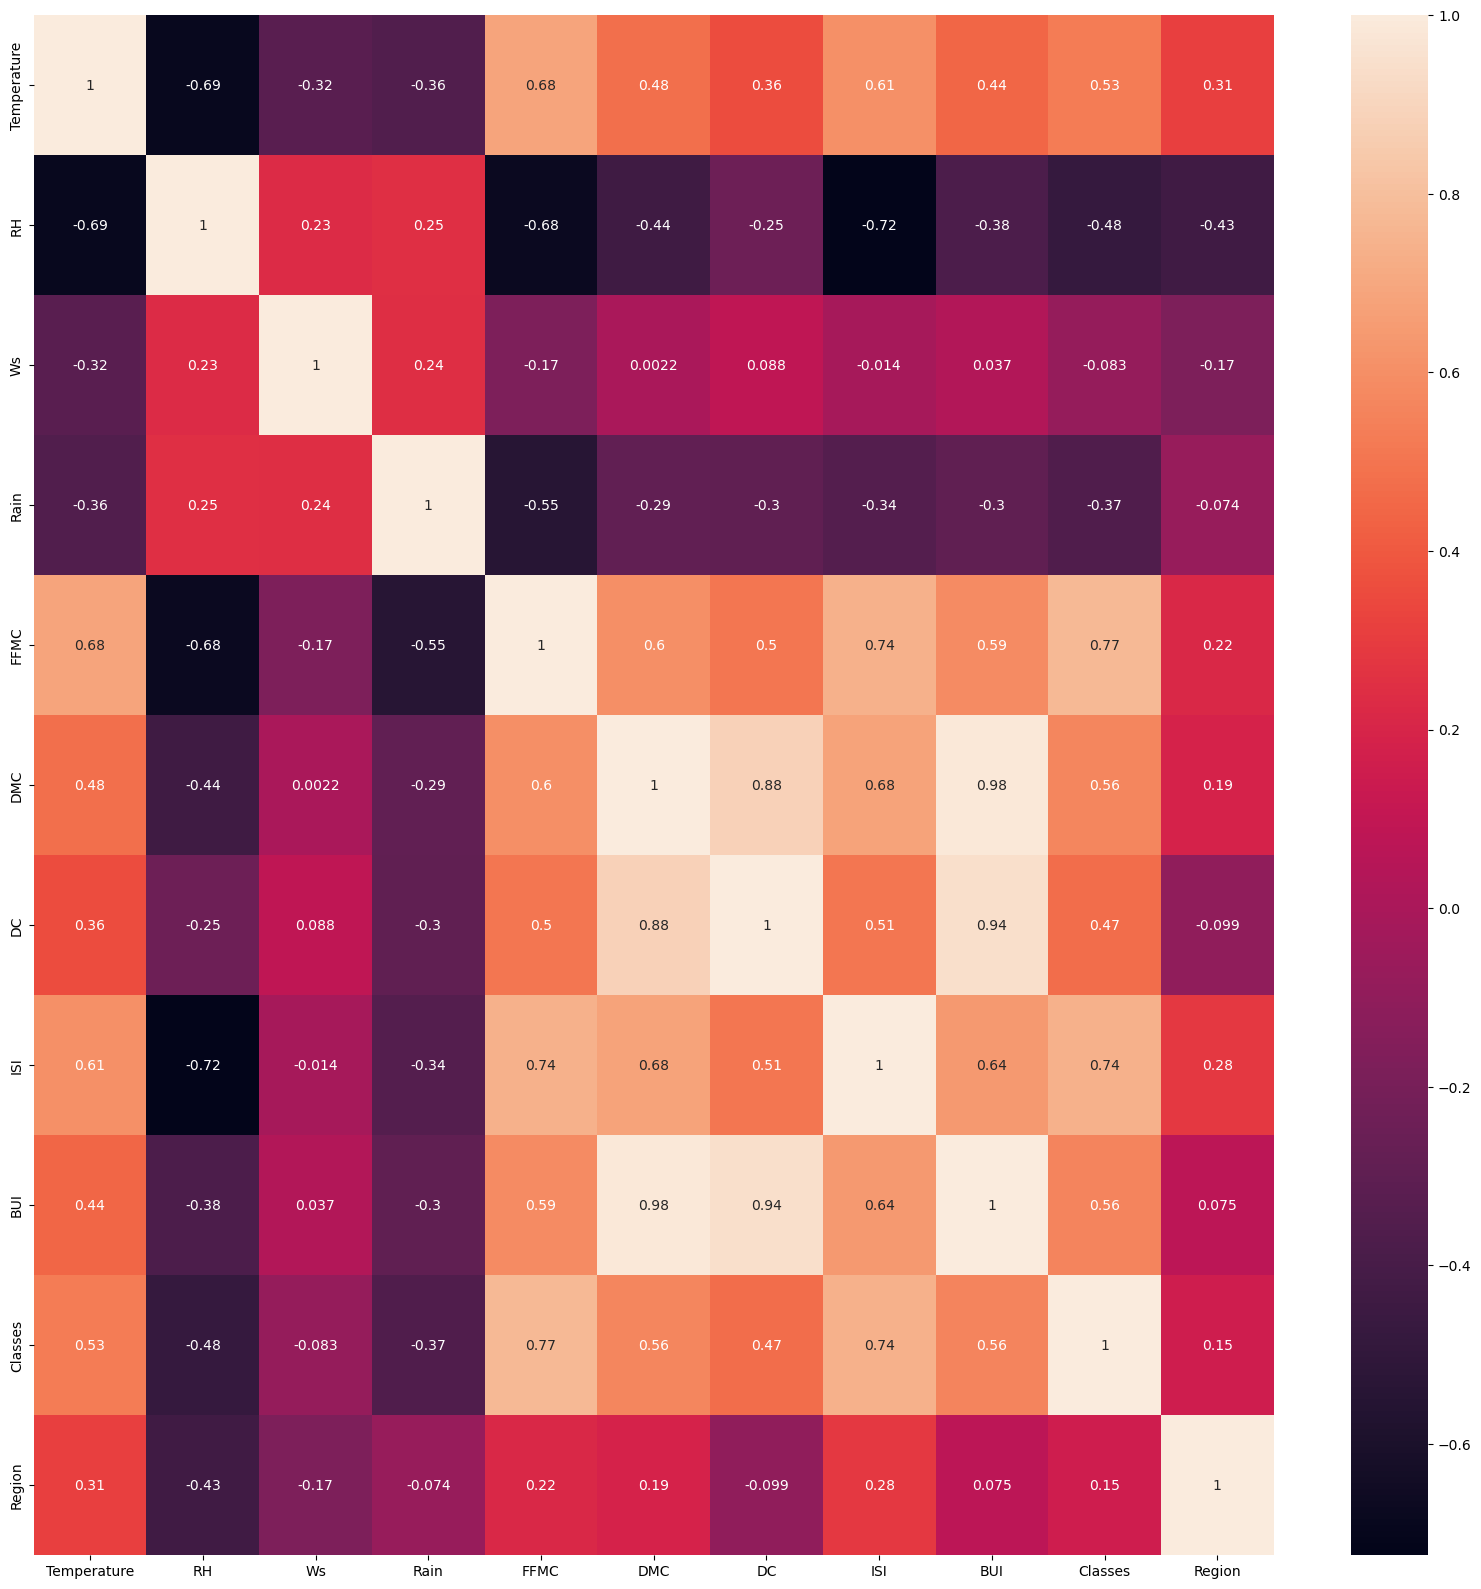

In [14]:
# check for multi-colinearity
# independent should not so much corelated

plt.figure(figsize=(20,20))

corr_X_train =  X_train.corr()
sns.heatmap(corr_X_train,annot=True)

#### highly co- related features are need to remove


In [15]:
def correlation(dataset, thresold):
    col_correlated = set()
    corr_matrix=  dataset.corr()
    for i in range (len(corr_matrix.columns)):
        for j in range(i):
            if abs(corr_matrix.iloc[i,j])> thresold: # abspolute value for handling both negative and positive corr
                col_name =corr_matrix.columns[i]
                col_correlated.add(col_name)
    print('highly corelated fetures : need to remove ')
    return col_correlated


In [16]:
# thresold is set up by domain expertise

# here we consider it as 0.85

correlated_features = correlation(X_train,0.85)
correlated_features

highly corelated fetures : need to remove 


{'BUI', 'DC'}

In [17]:
# drop features when correlation is more than 0.85

X_train.drop(correlated_features,axis=1,inplace = True)
X_test.drop(correlated_features,axis = 1,inplace =True)
X_train.shape,X_test.shape

((183, 9), (61, 9))

## Standardization and feature scaling


In [18]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

In [19]:
X_train_scaled= scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## Box Plots To understand Effect Of Standard Scaler

Text(0.5, 1.0, 'X train after feature scaling')

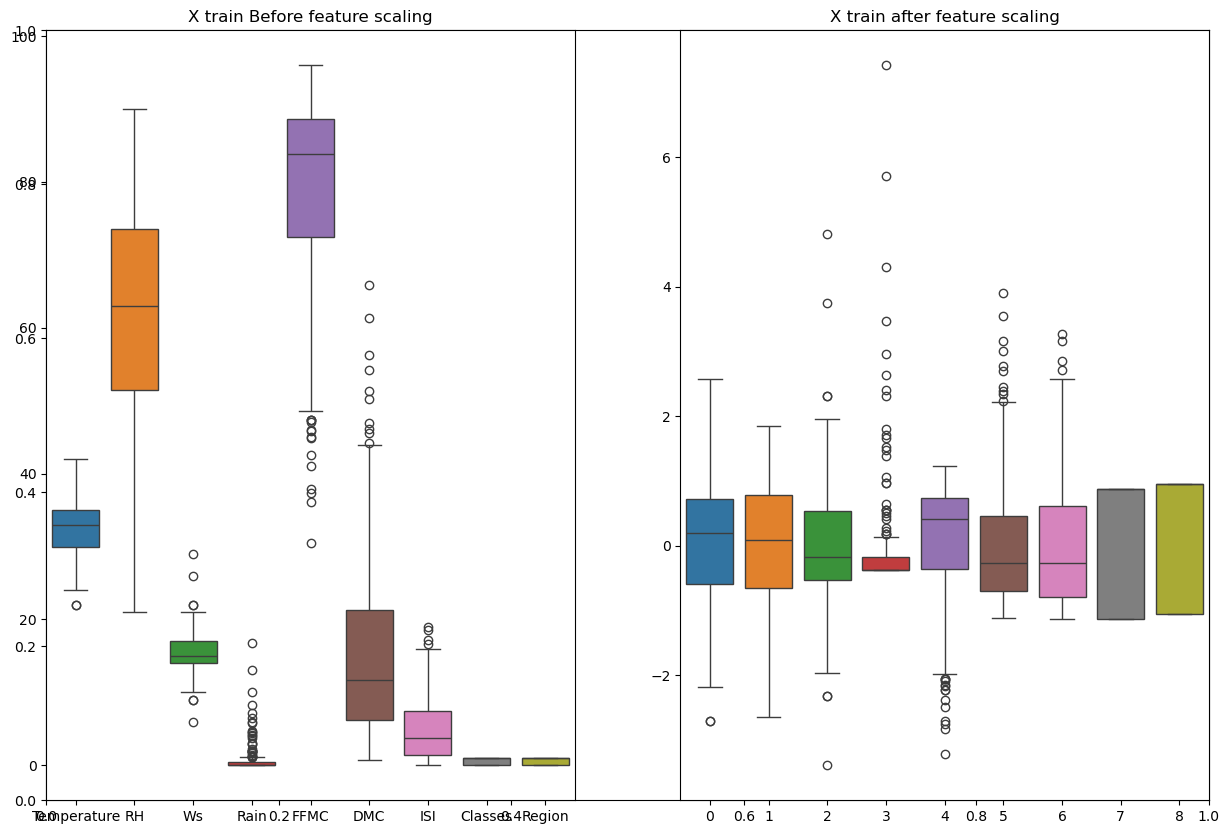

In [20]:
plt.subplots(figsize = (15,10))

plt.subplot(1,2,1)
sns.boxplot(data = X_train)
plt.title("X train Before feature scaling")

plt.subplot(1,2,2)
sns.boxplot(data = X_train_scaled)
plt.title("X train after feature scaling")


# Linear Regression

In [21]:
from sklearn.metrics import mean_absolute_error,r2_score

 mae :  0.6192406326223499
r2_score :  0.9809397590774558


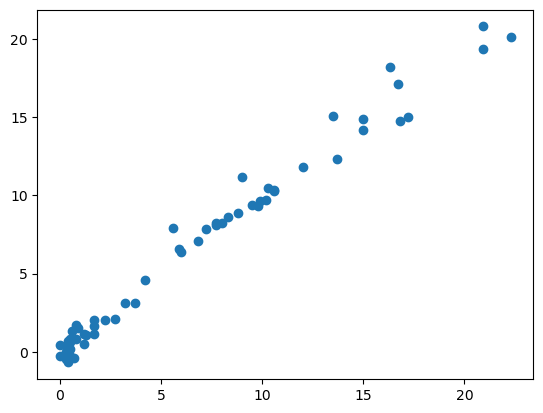

In [22]:
from sklearn.linear_model import LinearRegression

lin_reg = LinearRegression()

lin_reg.fit(X_train_scaled,y_train)
y_pred = lin_reg.predict(X_test_scaled)

mae =  mean_absolute_error(y_test,y_pred)
print(" mae : ",mae )

score = r2_score(y_test,y_pred)
print("r2_score : ", score)

plt.scatter(y_test,y_pred)


# Lasso

 mae :  1.0537899463232439
r2_score :  0.9504981594218009


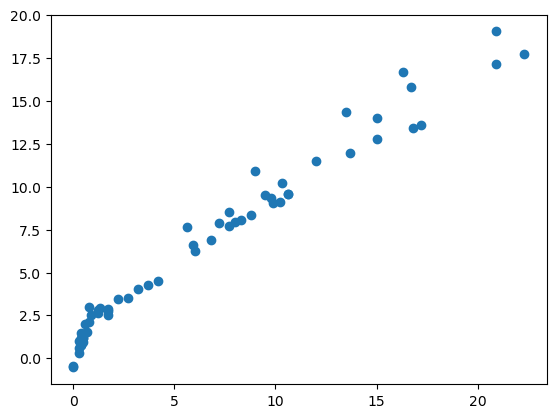

In [23]:
from sklearn.linear_model import Lasso

lasso_reg =  Lasso()

lasso_reg.fit(X_train_scaled,y_train)
y_pred = lasso_reg.predict(X_test_scaled)

mae =  mean_absolute_error(y_test,y_pred)
print(" mae : ",mae )

score = r2_score(y_test,y_pred)
print("r2_score : ", score)

plt.scatter(y_test,y_pred)


# LassoCV

In [24]:
from sklearn.linear_model import LassoCV
lassocv = LassoCV(cv = 5) # cv is also by default 5

lassocv.fit(X_train_scaled, y_train)

LassoCV(cv=5)

In [25]:
lassocv.predict(X_test_scaled)

array([ 3.13816649e+00,  1.32767324e+00,  9.60163816e+00,  9.30049679e+00,
        1.51987684e+01,  1.70907510e+00,  2.03260553e+00, -2.02033977e-01,
        7.96931442e+00,  2.41556176e+00,  8.47956665e+00,  1.75614020e+00,
        8.80931571e-01,  1.19088298e+01,  1.48606880e+01, -1.97908232e-02,
        2.00129291e+01,  1.04147142e+01,  9.50434262e-01,  8.44179866e+00,
        4.51514392e+00, -3.43237412e-01, -4.24777750e-01,  1.48543588e+01,
       -8.12391354e-02,  2.08170341e+01, -5.20050472e-01,  6.35573148e+00,
        9.73551174e+00,  1.54519823e+00,  1.14089414e+01,  1.14809733e-01,
        1.50277087e+01,  1.24222304e+01, -1.83227728e-01,  2.46239482e+00,
        1.34150905e+00,  6.32302101e-01,  1.02708751e+01,  3.62645326e-01,
        8.87536241e+00,  7.52452333e+00, -3.33467028e-01,  1.40531944e+01,
        7.04469656e+00,  3.92433323e-01,  1.48231394e+00,  1.02952688e+01,
        8.35047749e-01,  7.69922617e+00,  9.56867635e+00,  3.38387092e+00,
        3.61971238e-02,  

In [26]:
len(lassocv.alphas_)

100

In [27]:
lassocv.alphas_

array([7.06761429, 6.59128074, 6.14705048, 5.73275985, 5.34639102,
       4.98606216, 4.65001826, 4.33662259, 4.04434874, 3.77177317,
       3.51756829, 3.28049596, 3.05940151, 2.85320809, 2.66091141,
       2.48157489, 2.31432505, 2.15834728, 2.0128819 , 1.8772204 ,
       1.75070202, 1.63271057, 1.52267134, 1.42004839, 1.32434188,
       1.23508567, 1.15184503, 1.07421453, 1.00181606, 0.93429701,
       0.87132852, 0.8126039 , 0.75783711, 0.70676143, 0.65912807,
       0.61470505, 0.57327598, 0.5346391 , 0.49860622, 0.46500183,
       0.43366226, 0.40443487, 0.37717732, 0.35175683, 0.3280496 ,
       0.30594015, 0.28532081, 0.26609114, 0.24815749, 0.2314325 ,
       0.21583473, 0.20128819, 0.18772204, 0.1750702 , 0.16327106,
       0.15226713, 0.14200484, 0.13243419, 0.12350857, 0.1151845 ,
       0.10742145, 0.10018161, 0.0934297 , 0.08713285, 0.08126039,
       0.07578371, 0.07067614, 0.06591281, 0.0614705 , 0.0573276 ,
       0.05346391, 0.04986062, 0.04650018, 0.04336623, 0.04044

In [28]:
lassocv.alpha_

np.float64(0.03280495956225587)

In [29]:
lassocv.mse_path_

array([[68.45568226, 89.43743448, 50.51334991, 39.07008916, 45.51246544],
       [64.64966024, 89.43743448, 45.53071415, 34.9413288 , 39.66969377],
       [57.64758883, 83.40419285, 41.19660078, 30.45924981, 34.59133402],
       [51.30523901, 75.75868316, 36.6299784 , 26.56478345, 30.1776602 ],
       [44.88531065, 69.01514505, 32.33586884, 23.18097974, 26.3417734 ],
       [39.33449926, 63.06242191, 28.59765462, 20.24116788, 23.00835298],
       [34.5378733 , 57.80340905, 25.34295861, 17.68729862, 20.11169671],
       [30.3948228 , 51.50636605, 22.50903034, 15.4689971 , 17.59474153],
       [26.8182771 , 45.48297489, 20.04095218, 13.5421698 , 15.40778388],
       [23.73263755, 40.2139146 , 17.89192152, 11.86877052, 13.5078607 ],
       [21.0719357 , 35.60246995, 16.02024156, 10.41562447, 11.85735815],
       [18.77992249, 31.56491883, 14.38995954,  9.15388903, 10.42365724],
       [16.80677162, 28.02831402, 12.96979423,  8.05860008,  9.17839653],
       [15.10958087, 24.92908822, 11.7

In [30]:
len(lassocv.mse_path_)

100

 mae :  0.5735609331999771
r2_score :  0.9820339955095699


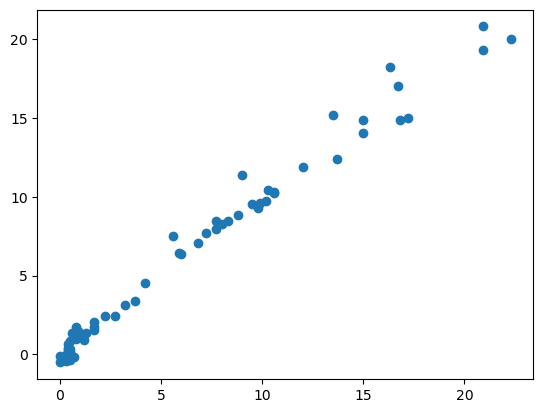

In [31]:
y_pred = lassocv.predict(X_test_scaled)
mae =  mean_absolute_error(y_test,y_pred)
print(" mae : ",mae )

score = r2_score(y_test,y_pred)
print("r2_score : ", score)

plt.scatter(y_test,y_pred)


# Ridge

 mae :  0.6248732555791736
r2_score :  0.980452351143696


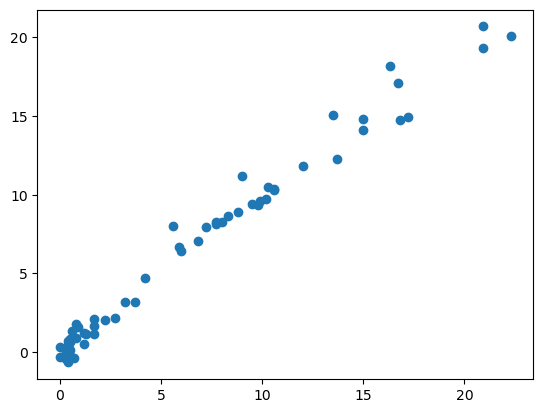

In [32]:
from sklearn.linear_model import Ridge

ridge_reg = Ridge()

ridge_reg.fit(X_train_scaled,y_train)
y_pred = ridge_reg.predict(X_test_scaled)

mae =  mean_absolute_error(y_test,y_pred)
print(" mae : ",mae )

score = r2_score(y_test,y_pred)
print("r2_score : ", score)

plt.scatter(y_test,y_pred)


# RidgeCV


In [33]:
from sklearn.linear_model import RidgeCV

ridgecv =RidgeCV(cv = 5) # default cv is leave one out  CV

ridgecv.fit(X_train_scaled,y_train)

y_pred = ridgecv.predict(X_test_scaled)

 mae :  0.6248732555791736
r2_score :  0.980452351143696


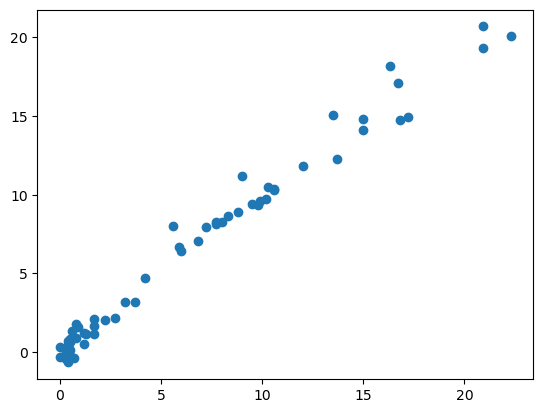

In [34]:
mae =  mean_absolute_error(y_test,y_pred)
print(" mae : ",mae )

score = r2_score(y_test,y_pred)
print("r2_score : ", score)

plt.scatter(y_test,y_pred)


In [35]:
ridgecv.alphas

(0.1, 1.0, 10.0)

# Elastic net

 mae :  1.634218644311761
r2_score :  0.8892602528583842


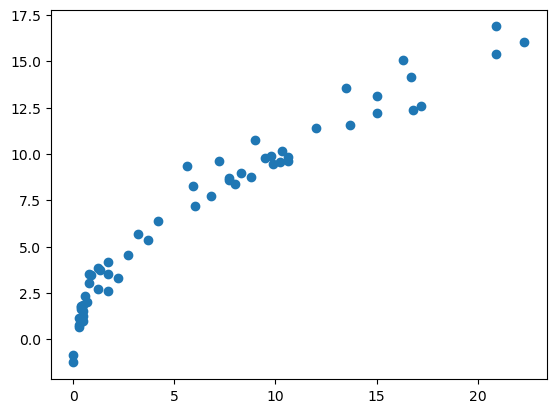

In [36]:
from sklearn.linear_model import ElasticNet

elasticnet_reg= ElasticNet()

elasticnet_reg.fit(X_train_scaled,y_train)
y_pred = elasticnet_reg.predict(X_test_scaled)

mae =  mean_absolute_error(y_test,y_pred)
print(" mae : ",mae )

score = r2_score(y_test,y_pred)
print("r2_score : ", score)

plt.scatter(y_test,y_pred)


# ElasticNetCV

 mae :  0.6119824394807016
r2_score :  0.9805119857539977


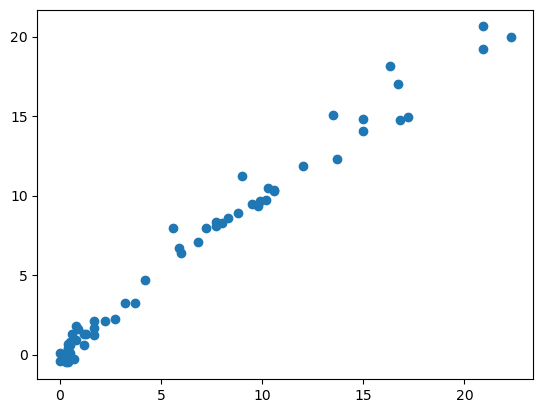

In [37]:
from sklearn.linear_model import ElasticNetCV

encv= ElasticNetCV(cv = 5) # default cv is leave one out  CV
# Elastic Net Cv has a property l1_ratio which focus on how much l1_norm is focused 
# byy default  l1_ratio is 0.5 which means l2_ratio is 0.5 also
encv.fit(X_train_scaled,y_train)

y_pred = encv.predict(X_test_scaled)
mae =  mean_absolute_error(y_test,y_pred)
print(" mae : ",mae )

score = r2_score(y_test,y_pred)
print("r2_score : ", score)

plt.scatter(y_test,y_pred)


# Pickling

### pickle the model and preprocessing from standard scaler

In [38]:
scaler

StandardScaler()

In [39]:
ridge_reg

Ridge()

In [40]:
import pickle

pickle.dump(ridge_reg, open("ridge.pkl",'wb'))
pickle.dump(scaler,open('scaler.pkl','wb'))